# Module 2 · Transformers — In-class Lab 🧪
## Attention as a soft dictionary lookup, then many heads

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mago-cinv/course-template/blob/master/modules/02-transformers/labs/in-class/lab-1-attention.ipynb)

### How this lab works

**The machinery is given to you** — attention, the multi-head block, the parameter formula, every plotting helper. You do not reimplement `softmax(QKᵀ/√d_k)V`.

**You write the investigation.** Four exercises run an experiment the notebook did not: what the **query** controls (E1), $\sqrt{d_k}$ **on trial** (E2), "$h$ heads cost the same as one" as a **measurement** (E3), and whether **cross-attention sees word order** (E4). A few lines of code each; the interpretation is the point.

Everything above a 🔬 section is your sandbox: read it, run it, take it apart.

*Runtime: seconds on CPU. No downloads, no training, no GPU.*

In [1]:
# Setup — run me first (works on Colab AND locally)
# This lab needs nothing beyond torch / numpy / matplotlib, which Colab already ships
# and which the course venv (.venv, environment/requirements.txt) already has.
import sys

if "google.colab" in sys.modules:
    %pip install -q matplotlib

print("Setup OK — running on", "Colab" if "google.colab" in sys.modules else "local Python")

Setup OK — running on local Python


In [2]:
# Imports + seeds — fixed seeds make every run (and every student) identical
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(0)
np.random.seed(0)
torch.set_printoptions(precision=4, sci_mode=False)

print("torch", torch.__version__, "— CPU only, no downloads in this notebook")

torch 2.13.0+cpu — CPU only, no downloads in this notebook


## 1 · The lab's anchor tensors (provided)

One tiny example, small enough to check by hand. Every exercise below is calibrated against it:

$$q=(1,0);\qquad k_1=(2,0),\ k_2=(0,2),\ k_3=(1,1);\qquad v_1=(1,0),\ v_2=(0,1),\ v_3=(1,1).$$

$n=3$ keys, $d_k = d_v = 2$. The scores come out $(2, 0, 1)$ — **a strict ranking, no ties**, so "which key won" always has one answer.

Note $V \neq K$ on purpose: the **keys** decide *where* the query looks, the **values** are *what it gets back*. Two different jobs, two different matrices.

In [3]:
# The anchor for the whole lab: one query, three keys, three values
q = torch.tensor([1.0, 0.0])                    # the query: "what am I looking for?"
K = torch.tensor([[2.0, 0.0],                   # k1  — strongly aligned with the query
                  [0.0, 2.0],                   # k2  — orthogonal to it
                  [1.0, 1.0]])                  # k3  — half aligned
V = torch.tensor([[1.0, 0.0],                   # v1  — what k1 hands over if attended to
                  [0.0, 1.0],                   # v2    (note: the values are NOT the keys)
                  [1.0, 1.0]])                  # v3
labels = ["k1", "k2", "k3"]

n, d_k = K.shape
d_v = V.shape[-1]
print(f"q     {tuple(q.shape)}  = {q.tolist()}")
print(f"K     {tuple(K.shape)}  (n={n} keys,   d_k={d_k})")
print(f"V     {tuple(V.shape)}  (n={n} values, d_v={d_v})")
print(f"\nraw scores q·k_j = {(K @ q).tolist()}   -> k1 > k3 > k2, a strict ranking")

q     (2,)  = [1.0, 0.0]
K     (3, 2)  (n=3 keys,   d_k=2)
V     (3, 2)  (n=3 values, d_v=2)

raw scores q·k_j = [2.0, 0.0, 1.0]   -> k1 > k3 > k2, a strict ranking


## 2 · Your toolkit (provided)

Six helpers. You call four of them directly; `attention` and `random_qk` do their work *inside* the other two.

| helper | what it gives you | who calls it |
|---|---|---|
| `attend_one(q, K, V, scale=True)` | dict with `scores`, `scaled`, `weights`, `output` — the four steps kept separate | you, in E1 |
| `score_stats(d_k, trials=50, scale=True, n=8)` | over `trials` seeded draws: the **mean of the per-draw score sd**, the mean **peak** weight, the mean row **entropy** | you, in E2 |
| `row_entropy(A)` | $-\sum_j A_{ij}\log A_{ij}$ per row; max is $\log n$ (uniform row) | you, in E1 |
| `show_weights(labels, weights, title)` | bar plot of one query's attention | you, in E1 |
| `attention(Q, K, V, scale=True, mask=None)` | `(out, A)` — the matrix form, row-wise softmax | internal (and the multi-head block, later) |
| `random_qk(d_k, n=8, seed=0)` | `(Q, K)` with i.i.d. $N(0,1)$ entries | internal, by `score_stats` |

`mask` is unused here — masking is Lesson 2's topic; the argument keeps the function unchanged for later.

In [4]:
# ══ THE TOOLKIT ══ provided; read it, then use it


def attend_one(q, K, V, scale=True):
    """One query attending over n keys/values — Lesson 1's four-step recipe, one step per dict entry.

    Returns dict with 'scores' (q·k_j), 'scaled' (÷√d_k), 'weights' (softmax) and 'output'
    (Σ_j A_j v_j). Kept separate so you can print the whole trace, not just the answer.
    """
    scores = K @ q                                   # (n,)  raw dot products
    scaled = scores / math.sqrt(K.shape[-1]) if scale else scores
    weights = torch.softmax(scaled, dim=-1)          # (n,)  a probability distribution
    return {"scores": scores, "scaled": scaled, "weights": weights, "output": weights @ V}


def attention(Q, K, V, scale=True, mask=None):
    """The matrix form: softmax(QKᵀ/√d_k)V (Lesson 1). Returns (out, A).

    mask (if given) is ADDED to the scores before the softmax — that is Lesson 2's topic.
    """
    S = Q @ K.transpose(-2, -1)
    if scale:
        S = S / math.sqrt(K.shape[-1])
    if mask is not None:
        S = S + mask
    A = torch.softmax(S, dim=-1)                     # each ROW sums to 1
    return A @ V, A


def random_qk(d_k, n=8, seed=0):
    """n queries and n keys with i.i.d. N(0,1) entries — Lesson 1's model of the input."""
    g = torch.Generator().manual_seed(seed)
    return torch.randn(n, d_k, generator=g), torch.randn(n, d_k, generator=g)


def row_entropy(A):
    """-Σ_j A_ij log A_ij per row. Uniform row -> log(n) (the maximum); one-hot row -> 0."""
    return -(A * A.clamp_min(1e-12).log()).sum(dim=-1)


def score_stats(d_k, trials=50, scale=True, n=8):
    """Average score sd / peak attention weight / row entropy over `trials` seeded draws.

    ONE draw is visibly noisy — averaging is what makes the √d_k trend readable (E2).
    """
    sds, peaks, ents = [], [], []
    for t in range(trials):
        Q, Kx = random_qk(d_k, n=n, seed=t)
        S = Q @ Kx.T
        if scale:
            S = S / math.sqrt(d_k)
        A = torch.softmax(S, dim=-1)
        sds.append(S.std().item())
        peaks.append(A.max(dim=-1).values.mean().item())
        ents.append(row_entropy(A).mean().item())
    return {"d_k": d_k, "scale": scale, "score_sd": float(np.mean(sds)),
            "peak_weight": float(np.mean(peaks)), "entropy": float(np.mean(ents)),
            "trials": trials}


def show_weights(labels, weights, title="", ax=None):
    """Bar plot of one query's attention distribution."""
    if ax is None:
        _, ax = plt.subplots(figsize=(3.2, 2.4))
    ax.bar(labels, np.asarray(weights), color="#3D5E8C")
    ax.set_ylim(0, 1)
    ax.set_ylabel("attention weight")
    ax.set_title(title, fontsize=10)
    return ax


print("toolkit ready — attend_one · attention · random_qk · row_entropy · score_stats · show_weights")

toolkit ready — attend_one · attention · random_qk · row_entropy · score_stats · show_weights


## 3 · Worked example — the anchor, step by step

The four steps, executed on the anchor. These are the numbers every exercise below is calibrated against.

1. scores  q·k_j         [2.0, 0.0, 1.0]
2. scale   ÷√d_k = ÷1.414  [1.414, 0.0, 0.707]
3. softmax weights A     [0.576, 0.14, 0.284]
4. output  Σ_j A_j v_j   [0.86, 0.424]

k1 wins with 57.6% of the attention; k2, the orthogonal key, gets 14.0%.


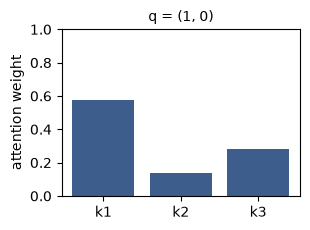

In [5]:
res = attend_one(q, K, V)

print("1. scores  q·k_j        ", [round(v, 3) for v in res["scores"].tolist()])
print(f"2. scale   ÷√d_k = ÷{math.sqrt(d_k):.3f} ", [round(v, 3) for v in res["scaled"].tolist()])
print("3. softmax weights A    ", [round(v, 3) for v in res["weights"].tolist()])
print("4. output  Σ_j A_j v_j  ", [round(v, 3) for v in res["output"].tolist()])

print(f"\nk1 wins with {res['weights'][0]:.1%} of the attention; k2, the orthogonal key, gets {res['weights'][1]:.1%}.")

show_weights(labels, res["weights"], "q = (1, 0)")
plt.tight_layout()
plt.show()

## 4 · Worked example — attention is a **set** function

Permute keys and values **together** and re-run. Watch what moves and what does not.

In [6]:
perm = [2, 0, 1]                       # k3, k1, k2  — same permutation applied to K and V
res_perm = attend_one(q, K[perm], V[perm])

print("original weights ", [round(v, 3) for v in res["weights"].tolist()], " labels", labels)
print("permuted weights ", [round(v, 3) for v in res_perm["weights"].tolist()],
      " labels", [labels[i] for i in perm])
print()
print("original output  ", [round(v, 3) for v in res["output"].tolist()])
print("permuted output  ", [round(v, 3) for v in res_perm["output"].tolist()])
print(f"\nmax abs difference in the OUTPUT: {(res['output'] - res_perm['output']).abs().max():.2e}")

original weights  [0.576, 0.14, 0.284]  labels ['k1', 'k2', 'k3']
permuted weights  [0.284, 0.576, 0.14]  labels ['k3', 'k1', 'k2']

original output   [0.86, 0.424]
permuted output   [0.86, 0.424]

max abs difference in the OUTPUT: 0.00e+00


The weights followed their keys; the output is **unchanged to machine precision**.

That is **order-blindness**: self-attention treats its input as a *set*. Nothing in the formula knows what order the tokens arrived in — which is why position must be **injected separately** (Lesson 2). E4 finds the same property on the *cross*-attention side.

## 5 · Worked example — one draw at $d_k = 64$

A single random draw, scaled and unscaled. Deliberately one draw — see the noise before E2 averages it away.

In [7]:
Q64, K64 = random_qk(64, n=8, seed=0)

S_raw = Q64 @ K64.T
S_scaled = S_raw / math.sqrt(64)
A_raw, A_scaled = torch.softmax(S_raw, -1), torch.softmax(S_scaled, -1)

print(f"d_k = 64,  √d_k = {math.sqrt(64):.1f}   (single draw, seed 0)")
print(f"  raw    score sd {S_raw.std():6.3f}   mean peak weight {A_raw.max(-1).values.mean():.3f}"
      f"   mean row entropy {row_entropy(A_raw).mean():.3f}")
print(f"  scaled score sd {S_scaled.std():6.3f}   mean peak weight {A_scaled.max(-1).values.mean():.3f}"
      f"   mean row entropy {row_entropy(A_scaled).mean():.3f}")
print(f"\n  (a uniform row over n=8 would have entropy log 8 = {math.log(8):.3f})")

d_k = 64,  √d_k = 8.0   (single draw, seed 0)
  raw    score sd  7.431   mean peak weight 0.861   mean row entropy 0.323
  scaled score sd  0.929   mean peak weight 0.325   mean row entropy 1.787

  (a uniform row over n=8 would have entropy log 8 = 2.079)


## 🔬 Exercise E1 — who does the query decide to attend to? *(~11 min)*

`K, V` stay **fixed**. Only the query changes.

Build **≥ 5 queries** over the same `K, V`, run `attend_one` on each, and collect one row per query in `probe_table`: the query, weights, output, winning key, row entropy.

Must include:

1. $q=(1,0)$ — the control;
2. $q=(0,1)$ — mirrored, same keys, opposite direction;
3. a **rescaled** copy — e.g. $3q$ *and* $0.2q$ (same direction, different length);
4. one query of your own.

Plot the weight distributions side by side. **Answer explicitly: what does the query's *direction* control, and what does its *length* control?**

query                scores           weights (k1,k2,k3)         output             win     peak  entropy
q=(1,0)  control     (2.0, 0.0, 1.0)  (0.576, 0.140, 0.284)      (0.860, 0.424)     k1     0.576    0.951
q=(0,1)  mirrored    (0.0, 2.0, 1.0)  (0.140, 0.576, 0.284)      (0.424, 0.860)     k2     0.576    0.951
3q       long        (6.0, 0.0, 3.0)  (0.882, 0.013, 0.106)      (0.987, 0.118)     k1     0.882    0.404
0.2q     short       (0.4, 0.0, 0.2)  (0.381, 0.287, 0.331)      (0.713, 0.619)     k1     0.381    1.092
q=(1,1)  diagonal    (2.0, 2.0, 2.0)  (0.333, 0.333, 0.333)      (0.667, 0.667)     tie    0.333    1.099

uniform over n=3 would be peak 0.333, entropy log 3 = 1.099 (the ceiling)


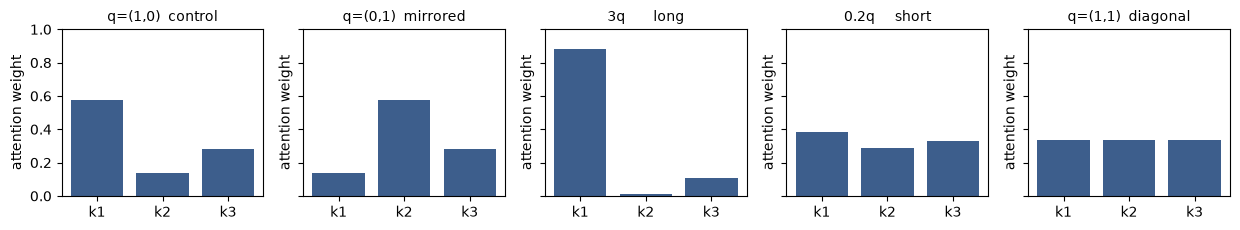

In [8]:
# E1 — se construyen 5 consultas (queries) distintas sobre los MISMOS K, V y se
# comparan sus distribuciones de atención: control, espejo, dos reescalados de la
# misma dirección (más larga / más corta) y una consulta "diagonal" propia.


def winner(w, labels, tol=1e-6):
    """Nombra la clave ganadora — o "tie" (empate) si las dos mayores no se distinguen."""
    top2 = torch.topk(w, 2).values                 # las dos probabilidades más altas
    return "tie" if (top2[0] - top2[1]) < tol else labels[int(w.argmax())]


# Las 5 consultas pedidas: control, espejo (misma norma, dirección ortogonal),
# la misma dirección alargada (3q) y acortada (0.2q), y una diagonal propia (1,1).
probes = {
    "q=(1,0)  control":  torch.tensor([1.0, 0.0]),
    "q=(0,1)  mirrored": torch.tensor([0.0, 1.0]),
    "3q       long":     torch.tensor([3.0, 0.0]),
    "0.2q     short":    torch.tensor([0.2, 0.0]),
    "q=(1,1)  diagonal": torch.tensor([1.0, 1.0]),
}

probe_table = {}
for name, qi in probes.items():
    r = attend_one(qi, K, V)                       # los 4 pasos de atención para esta consulta
    probe_table[name] = {
        "q": qi.tolist(),
        "scores": r["scores"].tolist(),
        "weights": r["weights"].tolist(),
        "output": r["output"].tolist(),
        "win": winner(r["weights"], labels),
        "entropy": row_entropy(r["weights"].unsqueeze(0)).item(),  # row_entropy espera un tensor 2-D
        "peak": r["weights"].max().item(),          # peso máximo = qué tan "afilada" es la distribución
    }

# Tabla resumen: una fila por consulta con scores, pesos, salida, ganador, pico y entropía
print(f"{'query':<20} {'scores':<16} {'weights (k1,k2,k3)':<26} {'output':<18} {'win':<5} {'peak':>6} {'entropy':>8}")
for name, r in probe_table.items():
    s = "(" + ", ".join(f"{v:.1f}" for v in r["scores"]) + ")"
    w = "(" + ", ".join(f"{v:.3f}" for v in r["weights"]) + ")"
    o = "(" + ", ".join(f"{v:.3f}" for v in r["output"]) + ")"
    print(f"{name:<20} {s:<16} {w:<26} {o:<18} {r['win']:<5} {r['peak']:6.3f} {r['entropy']:8.3f}")

# Referencia: una atención perfectamente uniforme sobre n=3 claves (el techo de entropía)
print(f"\nuniform over n={n} would be peak {1/n:.3f}, entropy log {n} = {math.log(n):.3f} (the ceiling)")

# Un subplot de barras por consulta, para comparar las 5 distribuciones lado a lado
fig, axes = plt.subplots(1, len(probe_table), figsize=(2.5 * len(probe_table), 2.4), sharey=True)
for ax, (name, r) in zip(axes, probe_table.items()):
    show_weights(labels, r["weights"], name, ax=ax)
plt.tight_layout()
plt.show()


> TODO: your answer here (4–5 sentences)

**Model answer.**

**Direction decides the ranking.** The control scores $(2,0,1)$ and $k_1$ wins with **57.6%**; the mirrored query scores $(0,2,1)$ and the winner moves to **$k_2$**, with the weights exactly swapped — **(0.576, 0.140, 0.284)** becomes **(0.140, 0.576, 0.284)**, and the output mirrors from **(0.860, 0.424)** to **(0.424, 0.860)**. Turning the query turns *who* it reads.

**Magnitude decides only the sharpness.** Scaling the query leaves the ranking $k_1 > k_3 > k_2$ completely untouched, but moves how decisive it is: at $3q$ the peak climbs $0.576 \to 0.882$ and entropy falls $0.951 \to 0.404$; at $0.2q$ the peak drops to $0.381$ and entropy rises to $1.092$, nearly the uniform ceiling $\log 3 = 1.099$. Same winner, very different confidence.

So the query carries two independent knobs:

- **direction** → *who* gets attended to (the ranking);
- **magnitude** → *how sharply* (the softmax's temperature).

**The diagonal query is the edge case worth keeping.** $q=(1,1)$ scores $(2,2,2)$ — it is equally aligned with all three keys, so the weights are exactly $(1/3, 1/3, 1/3)$ and the entropy sits at $\log 3 = 1.099$, the maximum possible. There is no winner to report. That is what "no preference at all" looks like numerically, and it is the ceiling every other row is measured against.

**Why this matters for E2.** Scaling a query up is indistinguishable from dropping the $\sqrt{d_k}$ divisor — both inflate the scores fed to the softmax and both push it toward a hard argmax. E2 shows the *dimension* doing it for free.

**Also notice:** every output lies inside the triangle spanned by $v_1, v_2, v_3$. The weights are non-negative and sum to 1, so the output is a **convex combination** of the values — attention can only interpolate between the values on offer.

## 🔬 Exercise E2 — put $\sqrt{d_k}$ on trial *(~12 min)*

Lesson 1 claims $q\cdot k$ grows like $\sqrt{d_k}$, so unscaled scores saturate the softmax as the model widens (its board poll: score sd ≈ 2, 8, 16 for $d_k = 4, 64, 256$). **Measure it.**

Sweep `d_k` over **≥ 4 values** — `[4, 16, 64, 256, 1024]` works — calling `score_stats(d_k, trials=..., scale=...)` **both ways**, into `dk_sweep`. Use **`trials >= 20`**; one draw is too noisy, as demo 5 showed.

Two plots:

1. raw score **sd** vs $d_k$, with $\sqrt{d_k}$ drawn on top. Use **log-log axes**: there the prediction $\text{sd} = \sqrt{d_k}$ is a straight line of **slope $\tfrac12$** (on linear axes it is a curve, which is much harder to read off).
2. mean **peak attention weight** vs $d_k$, scaled *and* unscaled, on one axis.

**Answer with your own numbers: at which $d_k$ has unscaled attention effectively become a hard argmax?**

   d_k    √d_k   raw sd  scaled sd  peak un  peak sc  ent un  ent sc
     4    2.00    1.981      0.991    0.565    0.372   1.196   1.704
    16    4.00    4.116      1.029    0.755    0.367   0.653   1.703
    64    8.00    8.047      1.006    0.856    0.352   0.355   1.726
   256   16.00   16.100      1.006    0.928    0.357   0.171   1.723
  1024   32.00   31.470      0.983    0.945    0.365   0.119   1.720

uniform baseline over n=8: peak 0.125, entropy log 8 = 2.079


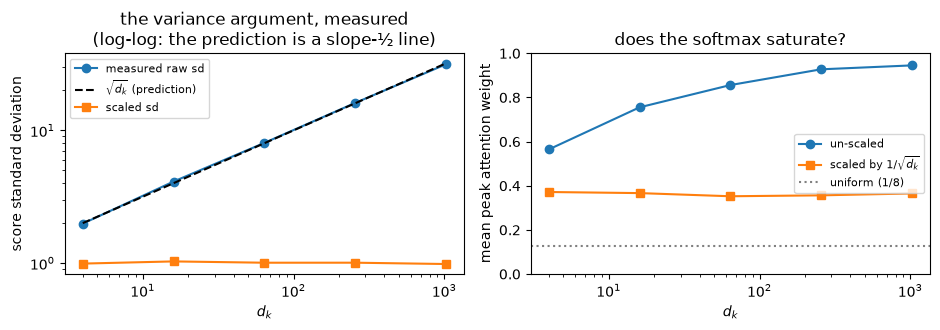

In [9]:
# E2 — se recorre d_k en 5 valores (de 4 a 1024) y, para cada uno, se promedian 20
# tiradas aleatorias CON y SIN el escalado por 1/√d_k, para medir su efecto sobre la softmax.

DKS = [4, 16, 64, 256, 1024]     # anchos de d_k a probar (≥4 valores pedidos)
TRIALS = 20                       # ≥20 tiradas para que la tendencia no sea puro ruido
N_KEYS = 8          # score_stats' default; the uniform baseline below is 1/N_KEYS

dk_sweep = {}
for dk in DKS:
    for sc in (False, True):      # sc=False -> sin escalar, sc=True -> escalado por √d_k
        dk_sweep[(dk, sc)] = score_stats(dk, trials=TRIALS, scale=sc, n=N_KEYS)

# Tabla: sd de los scores y peso pico/entropía promedio, con y sin escalado, por cada d_k
print(f"{'d_k':>6} {'√d_k':>7} {'raw sd':>8} {'scaled sd':>10} "
      f"{'peak un':>8} {'peak sc':>8} {'ent un':>7} {'ent sc':>7}")
for dk in DKS:
    u, s = dk_sweep[(dk, False)], dk_sweep[(dk, True)]
    print(f"{dk:6d} {math.sqrt(dk):7.2f} {u['score_sd']:8.3f} {s['score_sd']:10.3f} "
          f"{u['peak_weight']:8.3f} {s['peak_weight']:8.3f} {u['entropy']:7.3f} {s['entropy']:7.3f}")

# Línea base: atención perfectamente uniforme sobre n=8 claves
print(f"\nuniform baseline over n={N_KEYS}: peak {1/N_KEYS:.3f}, entropy log {N_KEYS} = {math.log(N_KEYS):.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.4))

# Panel izquierdo: sd de los scores vs d_k (ejes log-log) contra la predicción √d_k
ax1.plot(DKS, [dk_sweep[(d, False)]["score_sd"] for d in DKS], "o-", label="measured raw sd")
ax1.plot(DKS, [math.sqrt(d) for d in DKS], "k--", label=r"$\sqrt{d_k}$ (prediction)")
ax1.plot(DKS, [dk_sweep[(d, True)]["score_sd"] for d in DKS], "s-", label="scaled sd")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("$d_k$"); ax1.set_ylabel("score standard deviation")
ax1.set_title("the variance argument, measured\n(log-log: the prediction is a slope-½ line)")
ax1.legend(fontsize=8)

# Panel derecho: ¿se satura la softmax? peso pico promedio, escalado vs. sin escalar
ax2.plot(DKS, [dk_sweep[(d, False)]["peak_weight"] for d in DKS], "o-", label="un-scaled")
ax2.plot(DKS, [dk_sweep[(d, True)]["peak_weight"] for d in DKS], "s-",
         label=r"scaled by $1/\sqrt{d_k}$")
ax2.axhline(1 / N_KEYS, ls=":", c="grey", label=f"uniform (1/{N_KEYS})")
ax2.set_xscale("log"); ax2.set_ylim(0, 1)
ax2.set_xlabel("$d_k$"); ax2.set_ylabel("mean peak attention weight")
ax2.set_title("does the softmax saturate?"); ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


> TODO: tu respuesta aquí (4–5 oraciones)

**Respuesta.**

**La predicción se cumple.** La desviación estándar de los scores sin escalar es **1.981, 4.116, 8.047, 16.100 y 31.470** para $d_k = 4, 16, 64, 256, 1024$, contra la predicción $\sqrt{d_k} = 2, 4, 8, 16, 32$ — en ejes log-log los puntos medidos caen sobre la línea de pendiente ½ predicha. Al dividir por $\sqrt{d_k}$, la desviación estándar queda fija en **≈1.0 en todos los anchos**, tal como exige el argumento de varianza: $q\cdot k$ es la suma de $d_k$ términos independientes de varianza unitaria, así que $\operatorname{Var}(q\cdot k) = d_k$ y $\operatorname{Var}(q\cdot k/\sqrt{d_k}) = 1$.

**La consecuencia es peor que "números más grandes".** El peso pico promedio sin escalar sube **0.565 → 0.755 → 0.856 → 0.928 → 0.945**. Escalado, se mantiene plano en **≈0.35–0.37** en todo el barrido. La entropía cuenta la misma historia desde el otro lado: sin escalar colapsa de **1.196 a 0.119**, mientras que escalada se sostiene en **≈1.70–1.73** (el máximo uniforme sobre $n=8$ es $\log 8 = 2.079$).

**En $d_k = 256$ la atención sin escalar ya es, en la práctica, un argmax duro** — una clave se queda con ~93% del peso y las otras siete se reparten el resto. En $d_k = 1024$, ~95%.

**Por qué esto es grave.** Una softmax saturada casi no tiene gradiente: mover un score apenas cambia la salida, así que backprop no tiene de dónde aprender. Sin $\sqrt{d_k}$, hacer un modelo más ancho lo haría *más difícil* de entrenar, no más capaz. La solución cuesta una sola división.

**El mismo mecanismo que en E1, pero con otra causa.** Ahí nosotros inflamos los scores alargando la consulta a mano; aquí es la propia **dimensión** la que lo hace gratis, sin que nadie lo pida.

---

## 6 · Setup — two toy sequences (provided)

The rest of the lab uses a working **multi-head** block (Lesson 1's Part IV) to ask: if $h$ heads cost the same as one, what are you buying?

Lesson 1's running example — **"My paper lantern is beautiful."** → **"Mi linterna de papel es hermosa."** — needs two sequences: a 6-token English **source** and a 7-token Spanish **target**. ("paper lantern" resurfaces reordered as "linterna de papel" — that is E4's point.)

No trained model, no embedding table: each token gets a **seeded random** $d_{\text{model}}=8$ vector. Enough, because what this lab measures — shapes, parameter counts, row sums, permutation effects — is a property of the *architecture*, not the weights.

In [10]:
# The two toy sequences of Lesson 1's translation walkthrough, with seeded random embeddings
SRC = ["my", "paper", "lantern", "is", "beautiful", "."]        # English source (encoder side)
TGT = ["mi", "linterna", "de", "papel", "es", "hermosa", "."]   # Spanish target (decoder side)

D_MODEL = 8   # embedding width on the residual stream
H = 2         # default number of heads (E3 turns this knob)

_g = torch.Generator().manual_seed(0)                       # local generator = reproducible
X_src = torch.randn(len(SRC), D_MODEL, generator=_g)        # (6, 8)
X_tgt = torch.randn(len(TGT), D_MODEL, generator=_g)        # (7, 8)

print(f"SRC ({len(SRC)} tokens): {SRC}")
print(f"    X_src {tuple(X_src.shape)}   = (n_src, d_model)")
print(f"TGT ({len(TGT)} tokens): {TGT}")
print(f"    X_tgt {tuple(X_tgt.shape)}   = (n_tgt, d_model)")
print(f"\nd_model = {D_MODEL}, default h = {H}  ->  d_k = d_v = d_model/h = {D_MODEL // H}")

SRC (6 tokens): ['my', 'paper', 'lantern', 'is', 'beautiful', '.']
    X_src (6, 8)   = (n_src, d_model)
TGT (7 tokens): ['mi', 'linterna', 'de', 'papel', 'es', 'hermosa', '.']
    X_tgt (7, 8)   = (n_tgt, d_model)

d_model = 8, default h = 2  ->  d_k = d_v = d_model/h = 4


## 7 · The multi-head toolkit (provided)

Everything E3 and E4 need (plus `attention`, reused from Section 2).

| Tool | What it gives you |
|---|---|
| `make_projections(d_model=8, h=2, seed=0)` | a seeded set of weights: `WQ, WK, WV, WO` |
| `multi_head_attention(X, params, h, X_kv=None, mask=None)` | the whole block: `(out, per_head_A)`. **`X_kv` is the self→cross switch** |
| `param_count_mha(d_model, d_k, d_v, h)` | Lesson 1's equation (5), with the $W^Q,W^K,W^V$ and $W^O$ terms split out |
| `head_similarity(per_head_A)` | mean pairwise correlation of the heads' attention matrices |
| `mean_peak_weight(per_head_A)` | how peaked the average attention row is (1.0 = hard argmax, $1/n$ = uniform) |
| `heatmap(A, row_labels, col_labels, ax=None, title="")` | one attention matrix as a grid |

In [11]:
# ══ THE TOOLKIT ══ everything below is provided; read it, then use it in E3 / E4


def make_projections(d_model=8, h=2, seed=0):
    """The learned parameters of one MHA block — here just seeded random numbers.

    WQ, WK, WV : (d_model, d_model)   all h heads' projections stacked side by side,
                                      so head i uses the columns [i*d_k : (i+1)*d_k]
    WO         : (h*d_v, d_model)     the output mix (Lesson 1, equation (4)); with the usual
                                      sizing d_v = d_model/h this is (d_model, d_model)

    Entries are scaled by 1/sqrt(d_model) so the scores start in a sane range
    (unit-ish variance) instead of saturating the softmax immediately.
    """
    g = torch.Generator().manual_seed(seed)
    s = 1.0 / math.sqrt(d_model)
    return {
        "WQ": torch.randn(d_model, d_model, generator=g) * s,
        "WK": torch.randn(d_model, d_model, generator=g) * s,
        "WV": torch.randn(d_model, d_model, generator=g) * s,
        "WO": torch.randn(d_model, d_model, generator=g) * s,
        "d_model": d_model,
        "h": h,
    }


def _split_heads(M, h):
    """(n, d_model) -> (h, n, d_model//h): cut the FEATURE axis into h contiguous slices."""
    n, d = M.shape
    return M.reshape(n, h, d // h).transpose(0, 1)


def multi_head_attention(X, params, h, X_kv=None, mask=None):
    """The full multi-head block — Lesson 1's split -> per-head -> concat -> $W^O$ recipe, built on top of `attention` from Section 2.

    project -> split the feature axis into h heads of width d_k = d_model/h
            -> run `attention` inside each head -> concatenate -> apply W^O.

    X     (n_q, d_model)   supplies the QUERIES.
    X_kv  (n_kv, d_model)  supplies the KEYS and VALUES.
          * X_kv = None  -> keys/values come from X too      => SELF-attention
          * X_kv = other -> keys/values come from `other`     => CROSS-attention
          That one argument is the entire difference (Lesson 1, Part IV — equation (7)).

    Returns (out, per_head_A): out (n_q, d_model), per_head_A a list of h
    matrices of shape (n_q, n_kv) — one attention picture per head.
    """
    X_kv = X if X_kv is None else X_kv
    Q = X @ params["WQ"]        # (n_q,  d_model)
    K = X_kv @ params["WK"]     # (n_kv, d_model)
    V = X_kv @ params["WV"]     # (n_kv, d_model)

    Qh, Kh, Vh = _split_heads(Q, h), _split_heads(K, h), _split_heads(V, h)

    outs, per_head_A = [], []
    for i in range(h):
        head_out, A = attention(Qh[i], Kh[i], Vh[i], scale=True, mask=mask)
        outs.append(head_out)     # (n_q, d_v)
        per_head_A.append(A)      # (n_q, n_kv)

    concat = torch.cat(outs, dim=-1)          # (n_q, h*d_v) = (n_q, d_model)
    return concat @ params["WO"], per_head_A  # (n_q, d_model)


def param_count_mha(d_model, d_k, d_v, h):
    """Lesson 1's parameter formula, equation (5) — parameters of ONE multi-head attention block.

        N_MHA = h * d_model * (2*d_k + d_v)   (W^Q, W^K, W^V over all heads)
              + h * d_model * d_v             (W^O)
              = 2 * (d_k + d_v) * d_model * h

    Returns the terms separately so you can see where the budget goes.
    """
    qkv = h * d_model * (2 * d_k + d_v)
    wo = h * d_model * d_v
    return {"WQ_WK_WV": qkv, "WO": wo, "total": qkv + wo}


def head_similarity(per_head_A):
    """Mean pairwise Pearson correlation between the heads' FLATTENED attention matrices.

    ~1.0 = the heads are looking at the same thing;  ~0.0 = unrelated patterns;
    <0   = anti-correlated.  Returns nan when there is only one head (no pairs).
    """
    h = len(per_head_A)
    if h < 2:
        return float("nan")
    flat = torch.stack([A.flatten() for A in per_head_A])
    C = torch.corrcoef(flat)
    iu = torch.triu_indices(h, h, offset=1)      # the pairs above the diagonal
    return float(C[iu[0], iu[1]].mean())


def mean_peak_weight(per_head_A):
    """Average largest weight in an attention row, over all rows and all heads.

    1.0 means every query put all its mass on one key (a hard argmax);
    1/n_kv means perfectly uniform attention ("I looked at everything equally").
    """
    return float(torch.stack([A.max(dim=-1).values.mean() for A in per_head_A]).mean())


def heatmap(A, row_labels, col_labels, ax=None, title=""):
    """Lesson 1's heatmap convention: rows = queries (who is asking), cols = keys (who is read)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 3.6))
    im = ax.imshow(A.detach().numpy(), cmap="viridis", vmin=0.0)
    ax.set_xticks(range(len(col_labels)), col_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(row_labels)), row_labels, fontsize=8)
    ax.set_xlabel("keys (attended to)", fontsize=8)
    ax.set_ylabel("queries (asking)", fontsize=8)
    ax.set_title(title, fontsize=9)
    if A.numel() <= 64:                       # small enough to print the numbers
        for i in range(A.shape[0]):
            for j in range(A.shape[1]):
                ax.text(j, i, f"{A[i, j]:.2f}", ha="center", va="center",
                        fontsize=6, color="w")
    return im


# One shared set of weights, used by every demo below and available to you in E4.
PARAMS = make_projections(d_model=D_MODEL, h=H, seed=0)

print("toolkit ready — make_projections · multi_head_attention · param_count_mha · "
      "head_similarity · mean_peak_weight · heatmap  (attention() reused from Section 2)")
print(f"PARAMS: WQ/WK/WV {tuple(PARAMS['WQ'].shape)}, WO {tuple(PARAMS['WO'].shape)}")

toolkit ready — make_projections · multi_head_attention · param_count_mha · head_similarity · mean_peak_weight · heatmap  (attention() reused from Section 2)
PARAMS: WQ/WK/WV (8, 8), WO (8, 8)


## 8 · Worked example — the shape chase

The lesson's warm-up quiz, executed at $d_{\text{model}}=8$, $h=2$, $n=6$. Watch the feature axis get cut into heads and glued back together.

*Expected:* `(6,8) → per-head (6,4) → scores (6,6) → head out (6,4) → concat (6,8) → (6,8)`.

In [92]:
# Every intermediate shape of one multi-head self-attention block
X = X_src
d_k_head = D_MODEL // H

Q = X @ PARAMS["WQ"]
Qh = _split_heads(Q, H)
scores_head0 = Qh[0] @ _split_heads(X @ PARAMS["WK"], H)[0].T
out, per_head_A = multi_head_attention(X, PARAMS, h=H)

print(f"  input        X            {tuple(X.shape)}      (n, d_model)")
print(f"  project      Q = X @ WQ   {tuple(Q.shape)}      (n, d_model)   same for K, V")
print(f"  split        Q_i          {tuple(Qh[0].shape)}      (n, d_k) with d_k = d_model/h = {d_k_head}")
print(f"  score        Q_i K_i^T    {tuple(scores_head0.shape)}      (n, n)  <- the O(n^2) matrix")
print(f"  head output  head_i       {tuple((per_head_A[0] @ (X @ PARAMS['WV'])[:, :d_k_head]).shape)}      (n, d_v)")
print(f"  concat       [h_1||h_2]   ({X.shape[0]}, {H * d_k_head})      (n, h*d_v) = (n, d_model)")
print(f"  mix          @ WO         {tuple(out.shape)}      (n, d_model)")

print(f"\nin {tuple(X.shape)} -> out {tuple(out.shape)}: the block's output width EQUALS its input width.")
print("That invariant is what makes stacking N of these blocks — and adding the")
print("residual x + MHA(x) — possible at all. Residual connections are Lesson 4.")

  input        X            (6, 8)      (n, d_model)
  project      Q = X @ WQ   (6, 8)      (n, d_model)   same for K, V
  split        Q_i          (6, 4)      (n, d_k) with d_k = d_model/h = 4
  score        Q_i K_i^T    (6, 6)      (n, n)  <- the O(n^2) matrix
  head output  head_i       (6, 4)      (n, d_v)
  concat       [h_1||h_2]   (6, 8)      (n, h*d_v) = (n, d_model)
  mix          @ WO         (6, 8)      (n, d_model)

in (6, 8) -> out (6, 8): the block's output width EQUALS its input width.
That invariant is what makes stacking N of these blocks — and adding the
residual x + MHA(x) — possible at all. Residual connections are Lesson 4.


## 9 · Worked example — two heads, two pictures

Both heads read the **same** 6 English tokens; they differ only in which slice of the projected space they got.

*Expected:* two visibly different $6\times6$ heatmaps, every row summing to 1. The cell also prints how correlated the two heads' patterns are — **for this seed and for five others**, because a single seed says very little.

head 0: A (6, 6), max |row sum - 1| = 1.19e-07
head 1: A (6, 6), max |row sum - 1| = 1.19e-07


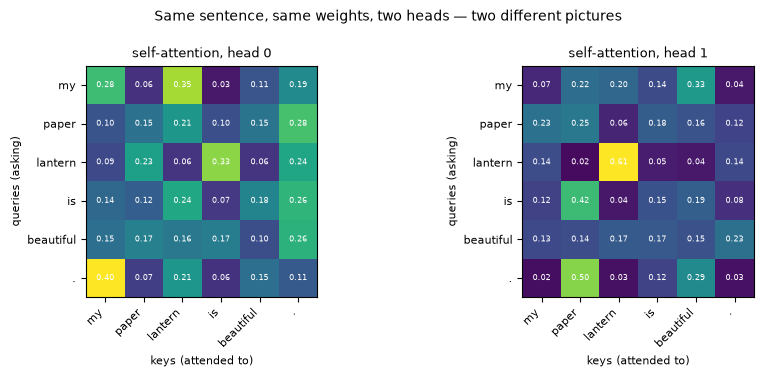

correlation between the two heads, THIS seed (0): -0.425
same measurement, seeds 0-5:      -0.425, +0.170, +0.246, +0.205, -0.088, -0.205

The sign flips from seed to seed — with untrained weights this number is noise.
E3 turns it into evidence by averaging 100 of them.


In [12]:
# Self-attention on the source sentence: one attention matrix per head
out_src, A_src = multi_head_attention(X_src, PARAMS, h=H)

for i, A in enumerate(A_src):
    dev = (A.sum(dim=-1) - 1).abs().max()
    print(f"head {i}: A {tuple(A.shape)}, max |row sum - 1| = {dev:.2e}")

fig, axes = plt.subplots(1, H, figsize=(9, 3.8))
for i, A in enumerate(A_src):
    heatmap(A, SRC, SRC, ax=axes[i], title=f"self-attention, head {i}")
fig.suptitle("Same sentence, same weights, two heads — two different pictures", fontsize=10)
fig.tight_layout()
plt.show()

# One seed is an anecdote. Re-run the SAME measurement on five more sets of random weights.
sims = []
for s in range(6):
    _, A_s = multi_head_attention(X_src, make_projections(D_MODEL, H, seed=s), h=H)
    sims.append(head_similarity(A_s))

print(f"correlation between the two heads, THIS seed (0): {sims[0]:+.3f}")
print("same measurement, seeds 0-5:      " + ", ".join(f"{v:+.3f}" for v in sims))
print("\nThe sign flips from seed to seed — with untrained weights this number is noise.")
print("E3 turns it into evidence by averaging 100 of them.")

## 10 · Worked example — cross-attention is rectangular

Change **one argument**: queries from the Spanish target, keys and values from the English source — `multi_head_attention(X_tgt, PARAMS, h=H, X_kv=X_src)`. The decoder asks, the encoder answers.

*Expected:* attention of shape **(7, 6)** — 7 Spanish queries over 6 English keys — with output still $(7, d_{\text{model}})$.

queries  from TGT  ->  7 rows
keys/values from SRC  ->  6 columns
attention matrix per head : (7, 6)   <- RECTANGULAR
block output              : (7, 8)   (one vector per TARGET token)


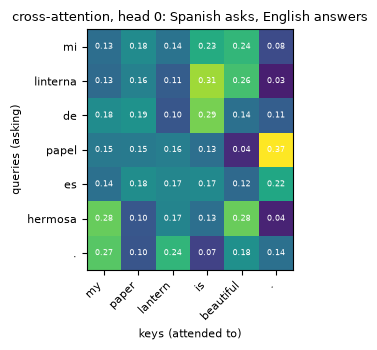

In [13]:
# Cross-attention: Q from the target, K and V from the source
out_cross, A_cross = multi_head_attention(X_tgt, PARAMS, h=H, X_kv=X_src)

print(f"queries  from TGT  ->  {len(TGT)} rows")
print(f"keys/values from SRC  ->  {len(SRC)} columns")
print(f"attention matrix per head : {tuple(A_cross[0].shape)}   <- RECTANGULAR")
print(f"block output              : {tuple(out_cross.shape)}   (one vector per TARGET token)")

heatmap(A_cross[0], TGT, SRC, title="cross-attention, head 0: Spanish asks, English answers")
plt.tight_layout()
plt.show()

---

## 🔬 Exercise E3 — what does splitting into heads actually buy? *(~13 min)*

The theory says $h$ heads of width $d_{\text{model}}/h$ cost "the same as one big head" (Lesson 1, equations (5)–(6)). That is a *claim*. **Turn it into a measurement.**

The demos above ran at $d_{\text{model}}=8$ so the heatmaps stayed readable. This exercise moves to $d_{\text{model}} = 512$ — the original Transformer's base width — because that is where the numbers mean something: at $h=8$ it gives $d_k = 64$, the real model's per-head width, and the parameter count lands on the same 1.05M Lesson 1 put on the board. E4 goes back to the small setting.

1. Sweep $h$ over **≥ 3 values** — `[1, 2, 4, 8]` works — at fixed $d_{\text{model}} = 512$, keeping $d_k = d_v = d_{\text{model}}/h$.
2. Record per $h$ in `head_sweep`: the **parameter count** (`param_count_mha`), the **number of attention matrices**, `head_similarity(...)`, and how far the **output** sits from the $h=1$ output (relative $L_2$ or cosine).
3. Plot **(i)** parameter count vs $h$ and **(ii)** mean head similarity vs $h$.

**Answer below:** what does the model *gain*, what does it *give up*, and — from your similarity numbers — can you honestly claim these heads specialized?

> One draw is noisy (section 9 showed the sign flipping). Averaging ~100 seeds of `make_projections` costs a couple of seconds and is the difference between a trend and an anecdote.

 h   d_k      params  #A            head sim  |out-out_1|/|out_1|   peak w
 1   512   1,048,576   1        n/a (1 head)                0.000    0.412
 2   256   1,048,576   2    -0.0201 ± 0.1856                0.544    0.419
 4   128   1,048,576   4    -0.0074 ± 0.0740                0.698    0.421
 8    64   1,048,576   8    -0.0005 ± 0.0357                0.779    0.419

breakdown at h=8: {'WQ_WK_WV': 786432, 'WO': 262144, 'total': 1048576}
4 * d_model^2 = 1,048,576   <- the 1.05M anchor Lesson 1 gave for the base model
uniform baseline 1/n = 1/6 = 0.167


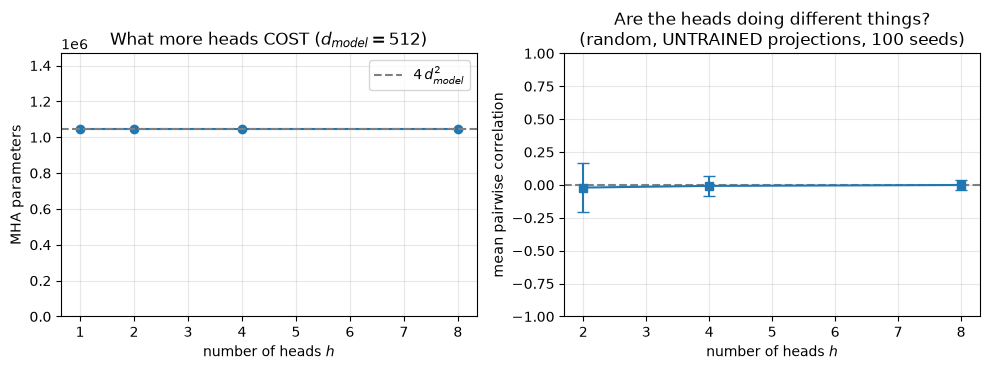

In [14]:
# E3 — se recorre el número de cabezas h manteniendo d_model=512 fijo (d_k=d_v=d_model/h),
# y se mide para cada h: el costo en parámetros y la similitud entre cabezas (¿se
# especializan o son puro ruido?), promediando 100 semillas para separar señal de ruido.

D_SWEEP = 512              # the original Transformer's base width -> at h=8, d_k = 64
H_VALUES = [1, 2, 4, 8]    # valores de h a comparar (≥3 pedidos)
SEEDS = range(100)         # average the random-projection noise away

# A fresh batch of 6 random token vectors at the real width (the d_model=8 embeddings
# of section 6 are the wrong shape for a 512-wide block).
_gs = torch.Generator().manual_seed(0)
X_sweep = torch.randn(len(SRC), D_SWEEP, generator=_gs)      # (6, 512)

head_sweep = {}
for h in H_VALUES:
    d_k = d_v = D_SWEEP // h    # tamaño de cabeza "estándar": se achica al crecer h
    sims, rel_diffs, peaks = [], [], []
    for s in SEEDS:
        p = make_projections(D_SWEEP, h, seed=s)         # SAME weights, different head split
        out_h, A_h = multi_head_attention(X_sweep, p, h=h)
        out_1, _ = multi_head_attention(X_sweep, p, h=1)   # the one-big-head reference
        sims.append(head_similarity(A_h))                  # correlación media entre cabezas
        rel_diffs.append(float((out_h - out_1).norm() / out_1.norm()))  # distancia relativa vs h=1
        peaks.append(mean_peak_weight(A_h))                 # qué tan "decidida" queda cada cabeza
    head_sweep[h] = {
        "d_k": d_k,
        "params": param_count_mha(D_SWEEP, d_k, d_v, h)["total"],   # parámetros totales del bloque
        "params_terms": param_count_mha(D_SWEEP, d_k, d_v, h),      # desglose WQ/WK/WV vs WO
        "n_attn": h,                                                 # una matriz de atención por cabeza
        "head_sim": float(np.mean(sims[1:])) if h == 1 else float(np.mean(sims)),
        "head_sim_sd": 0.0 if h == 1 else float(np.std(sims)),
        "rel_diff_vs_h1": float(np.mean(rel_diffs)),
        "peak_weight": float(np.mean(peaks)),
    }

# Tabla resumen por h: parámetros, número de matrices de atención, similitud entre
# cabezas (media ± desviación estándar), distancia relativa a h=1 y peso pico promedio
print(f"{'h':>2} {'d_k':>5} {'params':>11} {'#A':>3} {'head sim':>19} "
      f"{'|out-out_1|/|out_1|':>20} {'peak w':>8}")
for h, r in head_sweep.items():
    sim = "   n/a (1 head)" if h == 1 else f"{r['head_sim']:+.4f} ± {r['head_sim_sd']:.4f}"
    print(f"{h:>2} {r['d_k']:>5} {r['params']:>11,} {r['n_attn']:>3} {sim:>19} "
          f"{r['rel_diff_vs_h1']:>20.3f} {r['peak_weight']:>8.3f}")

print(f"\nbreakdown at h=8: {head_sweep[8]['params_terms']}")                 # desglose WQ/WK/WV vs WO en h=8
print(f"4 * d_model^2 = {4 * D_SWEEP ** 2:,}   <- the 1.05M anchor Lesson 1 gave for the base model")
print(f"uniform baseline 1/n = 1/{len(SRC)} = {1 / len(SRC):.3f}")            # línea base uniforme

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# Panel izquierdo: el costo en parámetros NO depende de h (línea plana en 4*d_model^2)
axes[0].plot(H_VALUES, [head_sweep[h]["params"] for h in H_VALUES], marker="o")
axes[0].axhline(4 * D_SWEEP ** 2, ls="--", c="grey", label=r"$4\,d_{model}^2$")
axes[0].set_ylim(0, 1.4 * 4 * D_SWEEP ** 2)
axes[0].set_xlabel("number of heads $h$")
axes[0].set_ylabel("MHA parameters")
axes[0].set_title(f"What more heads COST ($d_{{model}}={D_SWEEP}$)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel derecho: similitud media entre cabezas (con barras de error) vs h — ¿se especializan?
hh = [h for h in H_VALUES if h > 1]
axes[1].errorbar(hh, [head_sweep[h]["head_sim"] for h in hh],
                 yerr=[head_sweep[h]["head_sim_sd"] for h in hh],
                 marker="s", capsize=4)
axes[1].axhline(0, ls="--", c="grey")
axes[1].set_ylim(-1, 1)
axes[1].set_xlabel("number of heads $h$")
axes[1].set_ylabel("mean pairwise correlation")
axes[1].set_title(f"Are the heads doing different things?\n(random, UNTRAINED projections, {len(SEEDS)} seeds)")
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()


> TODO: tu respuesta aquí (4–5 oraciones)

**Respuesta** (barrido por defecto, $d_{\text{model}}=512$, 100 semillas — los valores de similitud cambian con las semillas y el rango; el conteo de parámetros no).

**El costo es exactamente cero.** El número de parámetros es **1,048,576 para cualquier $h$** — 786,432 en $W^Q,W^K,W^V$ más 262,144 en $W^O$, igual para $h = 1, 2, 4, 8$. Sustituyendo $d_k=d_v=d_{\text{model}}/h$ en la ecuación (5): $2(d_k+d_v)d_{\text{model}}h = 4d_{\text{model}}^2 = 4\cdot 512^2 = 1{,}048{,}576$ — la $h$ **se cancela**. Es el mismo 1.05M que la Lección 1 puso en el pizarrón para el modelo base, ahora medido. Lo que compra ese presupuesto fijo es el número de matrices de atención: 1, 2, 4 u 8. La "capacidad barata" es capacidad **gratis en patrones de atención**, pagada angostando cada cabeza.

**Es una función distinta, no una simple re-etiquetación.** La distancia $L_2$ relativa respecto a la salida con $h=1$ es **0.544** ($h=2$), **0.698** ($h=4$) y **0.779** ($h=8$). Mismos pesos, mismo presupuesto, cómputo genuinamente distinto.

**Estas cabezas no se especializaron.** La correlación media por pares, sobre 100 semillas, es **−0.0201 ± 0.1856** ($h=2$), **−0.0074 ± 0.0740** ($h=4$) y **−0.0005 ± 0.0357** ($h=8$) — indistinguible de cero, con una dispersión que ahoga a la media. Las cabezas no están relacionadas porque sus proyecciones aleatorias tampoco lo están, no porque se hayan repartido el trabajo. La especialización es **aprendida y emergente** (la Lección 1 lo advierte: las cabezas *no* vienen programadas de fábrica para tareas distintas), y necesita un entrenamiento que aquí no ocurrió.

**Por qué importa promediar.** Con $h=2$, una sola semilla oscila entre aproximadamente $-0.4$ y $+0.25$ — una tirada puede parecer un resultado dramático y ser puro ruido. Dos cosas reducen esa dispersión: más semillas y una $d_k$ más ancha. Con $d_{\text{model}}=8$ y 20 semillas, la dispersión en $h=2$ se dispara a $\approx 0.254$. La dispersión también baja con $h$ por una razón combinatoria: `head_similarity` promedia sobre los $\binom{h}{2}$ pares posibles, así que en $h=8$ cada semilla ya es un promedio de 28 comparaciones.

**Dónde sí pesa el compromiso — y dónde no.** El peso pico promedio se mantiene **plano** en todo el barrido (**0.412, 0.419, 0.421, 0.419**, contra el $1/6 = 0.167$ uniforme): incluso en $h=8$ cada cabeza conserva $d_k = 64$, de sobra para decir algo definido. El costo de angostar es real, pero solo se nota si $h$ se empuja hasta que $d_k$ colapsa a un dígito. Por eso los modelos reales eligen $h$ de forma que $d_k \approx 64$ en vez de maximizar $h$ — el presupuesto de parámetros nunca se queja, así que $h$ termina siendo una decisión de diseño.

---

## 🔬 Exercise E4 — self vs cross: does word order matter to the *asker*? *(~13 min)*

Section 10 showed cross-attention is rectangular, not what it *depends on*. Lesson 1 claims cross-attention is a **content-based lookup with no notion of source word order** — which is why "paper lantern" can resurface as "linterna de papel" at no cost. **Put that on trial.**

**Part 1.** Run all three configurations and record in `cross_probe` each one's attention shape, output shape, and how far its rows are from summing to 1:

| | queries from | keys / values from |
|---|---|---|
| self-attention (source) | `X_src` | `X_src` |
| self-attention (target) | `X_tgt` | `X_tgt` |
| cross-attention | `X_tgt` | `X_src` |

**Part 2.** **Permute the source** — `PERM = [0, 2, 1, 3, 4, 5]` moves "lantern" before "paper", mimicking the *linterna de papel* reordering. Re-run the cross-attention on it and compare against the un-permuted run:

- **(a)** the attention matrix — did the numbers change, and *where* did they go?
- **(b)** each target token's **output vector** — report the max absolute difference.

Heat-map the two attention matrices side by side.

**Answer below:** what happened, *why* (which of $Q$, $K$, $V$ moved?), and what does it force the architecture to add later?

self  src -> src:  A (6, 6)  out (6, 8)  max|row sum - 1| = 1.19e-07
self  tgt -> tgt:  A (7, 7)  out (7, 8)  max|row sum - 1| = 2.38e-07
cross tgt -> src:  A (7, 6)  out (7, 8)  max|row sum - 1| = 1.19e-07

source order : ['my', 'paper', 'lantern', 'is', 'beautiful', '.']
permuted     : ['my', 'lantern', 'paper', 'is', 'beautiful', '.']

(a) attention matrix, compared column-for-column : max|Δ| = 3.593e-01   <- it MOVED
    same comparison after re-ordering the columns : max|Δ| = 0.000e+00   <- identical
(b) target output vectors                         : max|Δ| = 5.960e-08   <- unchanged


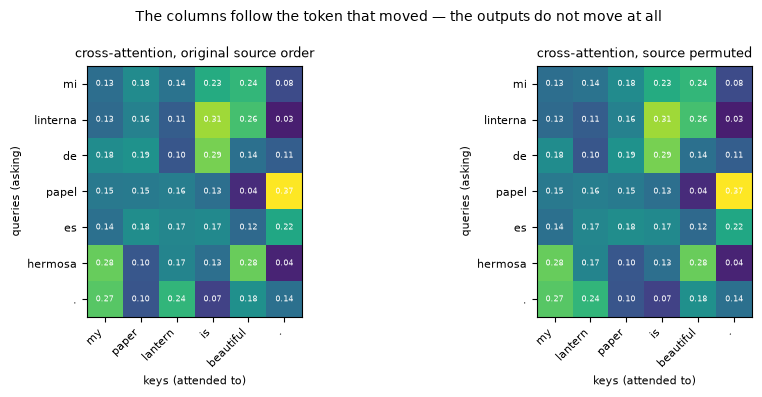

In [15]:
# E4, parte 1 — se corren las 3 configuraciones (self-atención en la fuente,
# self-atención en el objetivo y atención cruzada objetivo->fuente) y se guardan
# formas y sumas de fila en `cross_probe`.
cross_probe = {}
runs = {
    "self  src -> src": (X_src, None, SRC, SRC),   # Q, K, V — todos del inglés
    "self  tgt -> tgt": (X_tgt, None, TGT, TGT),    # Q, K, V — todos del español
    "cross tgt -> src": (X_tgt, X_src, TGT, SRC),   # Q del español, K/V del inglés
}
for name, (Xq, Xkv, rlab, clab) in runs.items():
    out, A = multi_head_attention(Xq, PARAMS, h=H, X_kv=Xkv)
    cross_probe[name] = {
        "attn_shape": tuple(A[0].shape),
        "out_shape": tuple(out.shape),
        "row_sum_dev": float(max((a.sum(-1) - 1).abs().max() for a in A)),  # debe ser ~0
    }
    print(f"{name}:  A {cross_probe[name]['attn_shape']}  out {cross_probe[name]['out_shape']}  "
          f"max|row sum - 1| = {cross_probe[name]['row_sum_dev']:.2e}")

# E4, parte 2 — se permuta el ORDEN de la fuente ("lantern" salta antes de "paper") y se
# vuelve a correr la atención cruzada, para ver si eso afecta a quien PREGUNTA (el target).
PERM = [0, 2, 1, 3, 4, 5]                     # "lantern" jumps in front of "paper"
SRC_PERM = [SRC[i] for i in PERM]
X_src_perm = X_src[PERM]
print(f"\nsource order : {SRC}\npermuted     : {SRC_PERM}")

out_ref, A_ref = multi_head_attention(X_tgt, PARAMS, h=H, X_kv=X_src)        # orden original
out_perm, A_perm = multi_head_attention(X_tgt, PARAMS, h=H, X_kv=X_src_perm)  # fuente permutada

# Comparación "cruda" columna por columna (SÍ cambia: las columnas son las claves permutadas)
attn_raw = float(max((ap - ar).abs().max() for ap, ar in zip(A_perm, A_ref)))
# Comparación tras deshacer la permutación en las columnas del original: si coinciden,
# la matriz solo se REORDENÓ, no cambió de contenido.
attn_unpermuted = float(max((ap - ar[:, PERM]).abs().max() for ap, ar in zip(A_perm, A_ref)))
out_diff = float((out_perm - out_ref).abs().max())   # diferencia en la salida del objetivo
cross_probe["permutation"] = {
    "perm": PERM,
    "attn_raw_diff": attn_raw,
    "attn_diff_after_undoing_perm": attn_unpermuted,
    "out_max_abs_diff": out_diff,
}

print(f"\n(a) attention matrix, compared column-for-column : max|Δ| = {attn_raw:.3e}   <- it MOVED")
print(f"    same comparison after re-ordering the columns : max|Δ| = {attn_unpermuted:.3e}   <- identical")
print(f"(b) target output vectors                         : max|Δ| = {out_diff:.3e}   <- unchanged")

# Mapas de calor lado a lado: orden original de la fuente vs. fuente permutada
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
heatmap(A_ref[0], TGT, SRC, ax=axes[0], title="cross-attention, original source order")
heatmap(A_perm[0], TGT, SRC_PERM, ax=axes[1], title="cross-attention, source permuted")
fig.suptitle("The columns follow the token that moved — the outputs do not move at all", fontsize=10)
fig.tight_layout()
plt.show()


> TODO: tu respuesta aquí (4–5 oraciones)

**Respuesta** (`PERM = [0, 2, 1, 3, 4, 5]`, $h=2$).

**Parte 1.** Las tres configuraciones dan atención fila-estocástica (max $|{\rm suma\ de\ fila}-1| \approx 1.2\times10^{-7}$, ruido propio de float32), pero solo la atención cruzada es **rectangular**: la self-atención en la fuente es $(6,6)$, en el objetivo es $(7,7)$, y la cruzada es $(7,6)$ — 7 consultas en español sobre 6 claves en inglés. La salida siempre tiene forma $(n_q, d_{\text{model}})$: un vector por cada token que **pregunta**. Las filas vienen del flujo de consultas; las columnas, del flujo de claves/valores.

**Parte 2 — qué se movió.** Comparando columna por columna, las dos matrices de atención cruzada difieren hasta en **0.359** — grande para números en $[0,1]$. Pero al comparar la corrida permutada contra el original *reordenando sus columnas con la misma permutación*, la diferencia cae a **5.96e-08**: la matriz no cambió de contenido, solo se **reordenó**. La salida de cada token del objetivo cambia, como mucho, **5.96e-08** — precisión de máquina, es decir, no cambia en absoluto.

**Por qué.** $Q$ viene de `X_tgt`, que no se toca. $K$ y $V$ se construyen ambas a partir de la fuente, así que las dos quedan permutadas por la misma $P$: los scores se vuelven $Q(PK)^\top = (QK^\top)P^\top$; la softmax actúa fila por fila, así que conmuta con una permutación de columnas; luego $(AP^\top)(PV) = AV$ — la permutación se cancela. La atención cruzada es una **búsqueda basada en contenido**: recupera *qué* hay en la fuente, no *dónde* estaba sentado. Por eso "paper lantern" puede resurgir como "linterna de papel" sin ningún costo.

**La otra cara de la moneda.** Es la misma ceguera al orden que la Sección 4 encontró en la self-atención: la atención es una **función de conjunto**. El reordenamiento libre entre idiomas y la ceguera total al orden de las palabras son la misma propiedad vista desde dos lados — y por eso la posición debe inyectarse en los vectores de los tokens *antes* de que la atención los vea (Lección 2). Sin eso, este modelo no podría distinguir "el perro mordió al hombre" de "el hombre mordió al perro".